# PROJEKT ZALICZENIOWY Z UCZENIA MASZYNOWGO
## PATRYK RYCHŁY 21530
## TEMAT: DELAY REASONS/ POWODY OPÓŹNIEŃ LOTÓW .

In [1]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler


import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
path = kagglehub.dataset_download("usdot/flight-delays")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\patry\.cache\kagglehub\datasets\usdot\flight-delays\versions\1


In [3]:
df = pd.read_csv(path + '/flights.csv')
df

C:\Users\patry\AppData\Local\Temp\ipykernel_14800\1747407598.py:1: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + '/flights.csv')


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,...,753.0,-26.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,...,430.0,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,...,432.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,...,330.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
pd.set_option('display.max_columns',None)
df.head(10)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,20.0,-5.0,18.0,38.0,217.0,230.0,206.0,1589,604.0,6.0,602,610.0,8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,19.0,-6.0,11.0,30.0,181.0,170.0,154.0,1299,504.0,5.0,526,509.0,-17.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,44.0,14.0,13.0,57.0,273.0,249.0,228.0,2125,745.0,8.0,803,753.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,19.0,-11.0,17.0,36.0,195.0,193.0,173.0,1464,529.0,3.0,545,532.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,33.0,3.0,12.0,45.0,221.0,203.0,186.0,1747,651.0,5.0,711,656.0,-15.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


# SORTUJE DANE ABY MODEL MÓGŁ PRZEWIDZIEĆ CZY LOT BĘDZIE OPÓŹNIONY I DLACZEGO.

In [5]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='str')

In [6]:
df= df[['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY',
        'DISTANCE',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']]


In [7]:
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,ANC,SEA,5,2354.0,-11.0,1448,430,408.0,-22.0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,LAX,PBI,10,2.0,-8.0,2330,750,741.0,-9.0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,SFO,CLT,20,18.0,-2.0,2296,806,811.0,5.0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,LAX,MIA,20,15.0,-5.0,2342,805,756.0,-9.0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,SEA,ANC,25,24.0,-1.0,1448,320,259.0,-21.0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,LAX,BOS,2359,2355.0,-4.0,2611,819,753.0,-26.0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819075,2015,12,31,4,B6,JFK,PSE,2359,2355.0,-4.0,1617,446,430.0,-16.0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819076,2015,12,31,4,B6,JFK,SJU,2359,2350.0,-9.0,1598,440,432.0,-8.0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819077,2015,12,31,4,B6,MCO,SJU,2359,2353.0,-6.0,1189,340,330.0,-10.0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
missing_counts = df.isna().sum()
missing_counts

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
DISTANCE                     0
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

In [9]:
reasons_missing_values = df[df['AIR_SYSTEM_DELAY'].isna() & df['SECURITY_DELAY'].isna() & df['AIRLINE_DELAY'].isna() & df['LATE_AIRCRAFT_DELAY'].isna() & df['WEATHER_DELAY'].isna()]
reasons_missing_values.shape

(4755640, 21)

array([[<Axes: title={'center': 'YEAR'}>,
        <Axes: title={'center': 'MONTH'}>,
        <Axes: title={'center': 'DAY'}>,
        <Axes: title={'center': 'DAY_OF_WEEK'}>],
       [<Axes: title={'center': 'SCHEDULED_DEPARTURE'}>,
        <Axes: title={'center': 'DEPARTURE_TIME'}>,
        <Axes: title={'center': 'DEPARTURE_DELAY'}>,
        <Axes: title={'center': 'DISTANCE'}>],
       [<Axes: title={'center': 'SCHEDULED_ARRIVAL'}>,
        <Axes: title={'center': 'ARRIVAL_TIME'}>,
        <Axes: title={'center': 'ARRIVAL_DELAY'}>,
        <Axes: title={'center': 'CANCELLED'}>],
       [<Axes: title={'center': 'AIR_SYSTEM_DELAY'}>,
        <Axes: title={'center': 'SECURITY_DELAY'}>,
        <Axes: title={'center': 'AIRLINE_DELAY'}>,
        <Axes: title={'center': 'LATE_AIRCRAFT_DELAY'}>],
       [<Axes: title={'center': 'WEATHER_DELAY'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

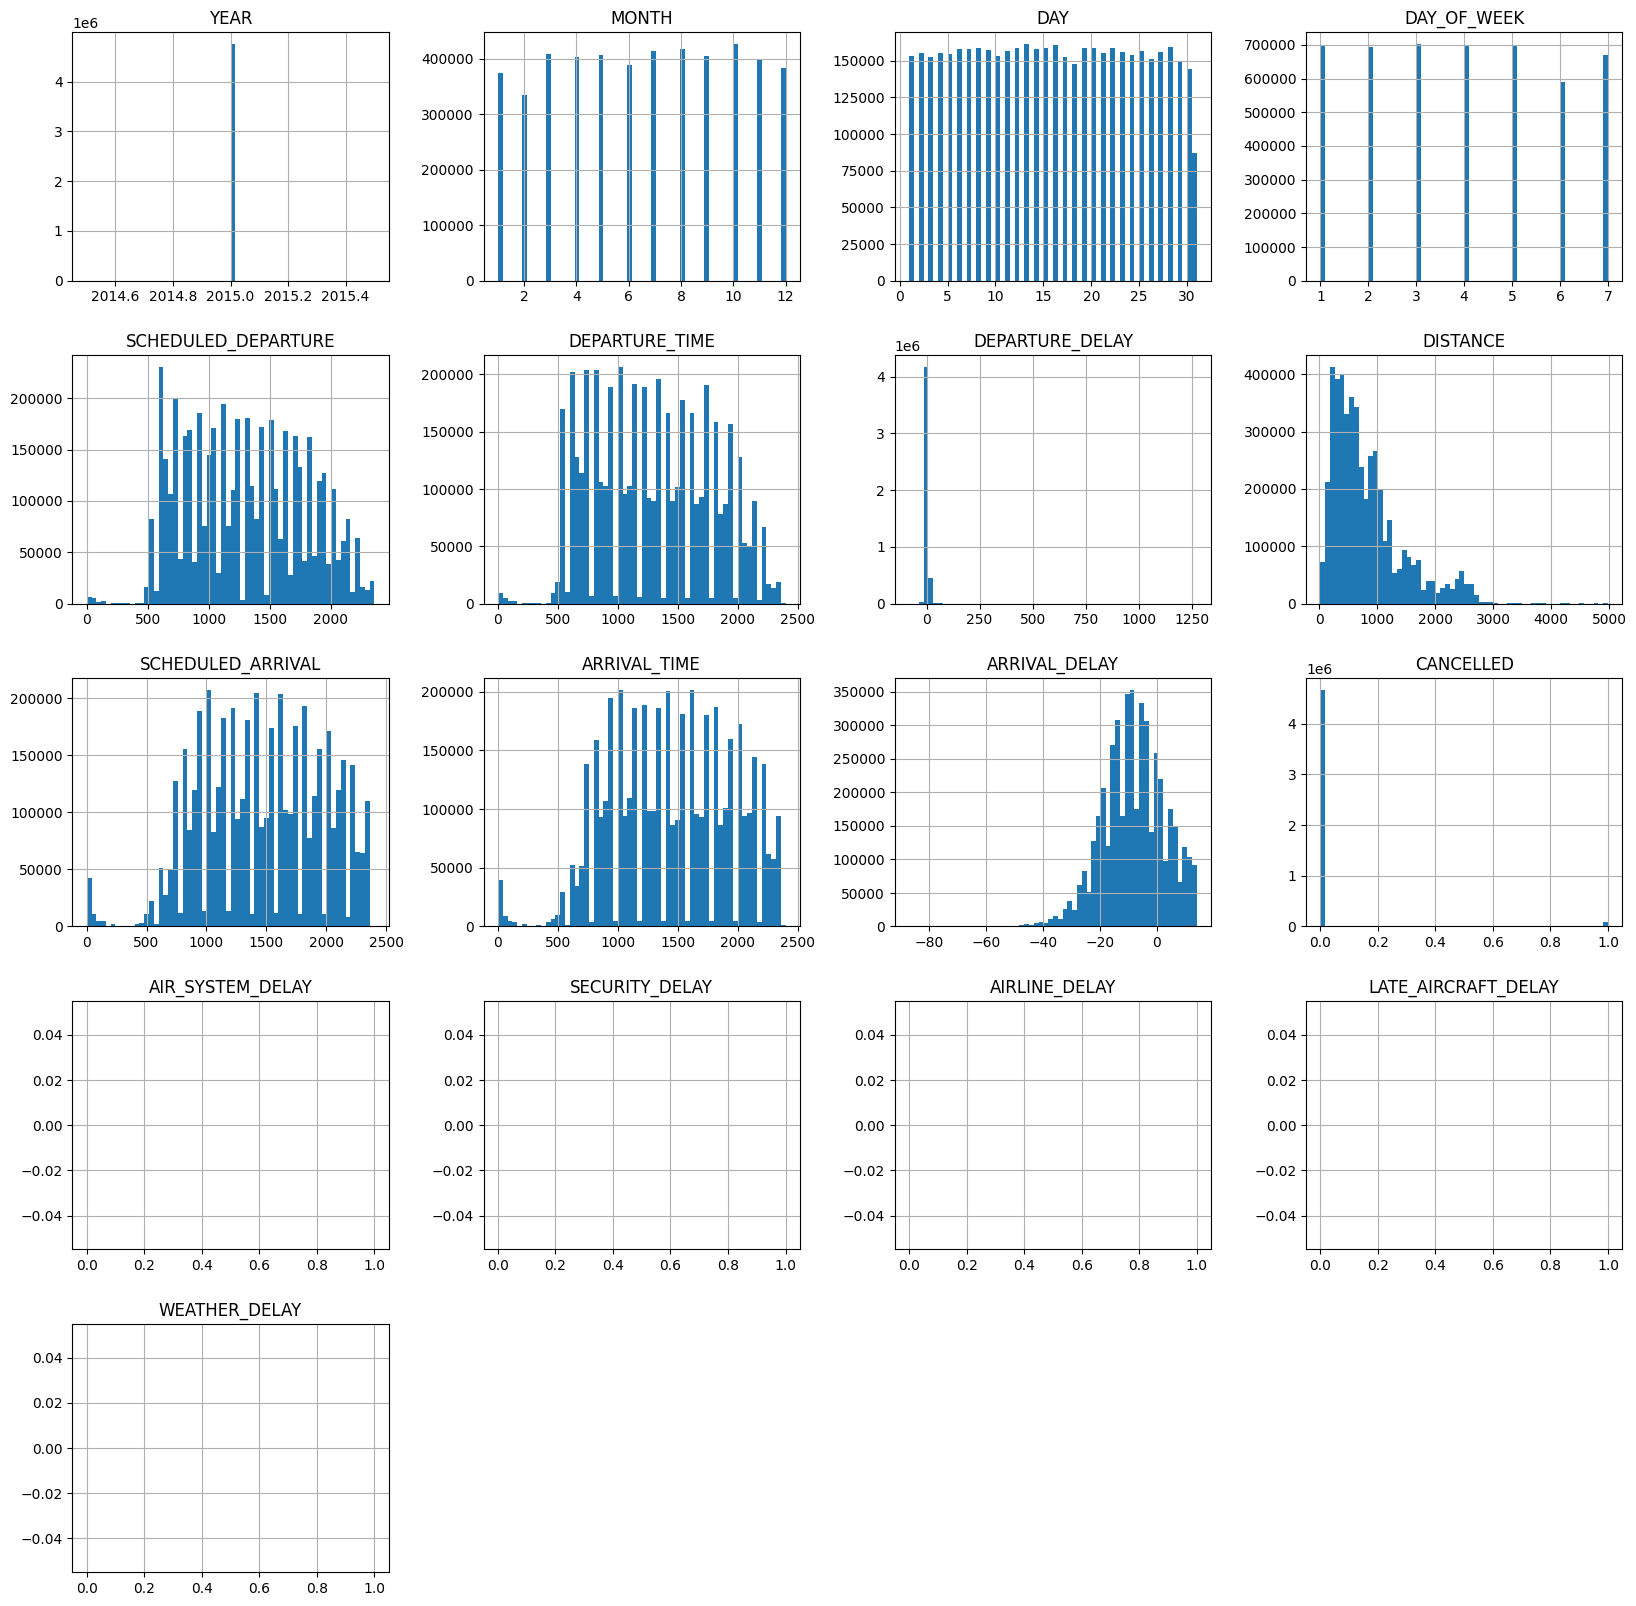

In [10]:
reasons_missing_values.hist(bins=60, figsize=(20,20))

In [11]:
reasons_missing_values[reasons_missing_values['ARRIVAL_DELAY']>13]

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
94,2015,1,1,4,UA,IAD,IAH,535,541.0,6.0,1190,802,816.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
109,2015,1,1,4,EV,ATL,IAD,540,556.0,16.0,534,725,739.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
181,2015,1,1,4,UA,RNO,DEN,600,557.0,-3.0,804,910,924.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
204,2015,1,1,4,AA,MIA,PHL,600,604.0,4.0,1013,844,858.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
490,2015,1,1,4,F9,SLC,DEN,615,617.0,2.0,391,747,801.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5817972,2015,12,31,4,DL,DTW,LGA,1940,2009.0,29.0,502,2126,2140.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
5818194,2015,12,31,4,NK,FLL,DTW,2005,2029.0,24.0,1127,2305,2319.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
5818308,2015,12,31,4,B6,LGB,OAK,2015,2033.0,18.0,353,2132,2146.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN
5818644,2015,12,31,4,B6,PDX,JFK,2120,2114.0,-6.0,2454,518,532.0,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN


#LOTY KTÓRE WYLĄDOWAŁY POWYŻEJ 13 MINUT OPÓŹNIENIA NIE SĄ UZNAWANE ZA OPÓŹNIONE

In [12]:
arrival_delay = df[df['ARRIVAL_DELAY'].isna()]

In [13]:
arrival_delay['CANCELLED'].value_counts()

CANCELLED
1    89884
0    15187
Name: count, dtype: int64

#potrzebujemy tylko loty z arrival_delay

In [14]:
df=df[~df['ARRIVAL_DELAY'].isna()]
df.shape

(5714008, 21)

In [15]:
df.isna().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME               0
DEPARTURE_DELAY              0
DISTANCE                     0
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME                 0
ARRIVAL_DELAY                0
CANCELLED                    0
CANCELLATION_REASON    5714008
AIR_SYSTEM_DELAY       4650569
SECURITY_DELAY         4650569
AIRLINE_DELAY          4650569
LATE_AIRCRAFT_DELAY    4650569
WEATHER_DELAY          4650569
dtype: int64

#WYPEŁNIAMY ZERAMI WARTOŚCI NaN W NASZYCH POWODACH OPÓŹNIEŃ

In [16]:
df.loc[:,['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']]=df[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].fillna(0)


In [17]:
df

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,ANC,SEA,5,2354.0,-11.0,1448,430,408.0,-22.0,0,NaN,0.0,0.0,0.0,0.0,0.0
1,2015,1,1,4,AA,LAX,PBI,10,2.0,-8.0,2330,750,741.0,-9.0,0,NaN,0.0,0.0,0.0,0.0,0.0
2,2015,1,1,4,US,SFO,CLT,20,18.0,-2.0,2296,806,811.0,5.0,0,NaN,0.0,0.0,0.0,0.0,0.0
3,2015,1,1,4,AA,LAX,MIA,20,15.0,-5.0,2342,805,756.0,-9.0,0,NaN,0.0,0.0,0.0,0.0,0.0
4,2015,1,1,4,AS,SEA,ANC,25,24.0,-1.0,1448,320,259.0,-21.0,0,NaN,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,LAX,BOS,2359,2355.0,-4.0,2611,819,753.0,-26.0,0,NaN,0.0,0.0,0.0,0.0,0.0
5819075,2015,12,31,4,B6,JFK,PSE,2359,2355.0,-4.0,1617,446,430.0,-16.0,0,NaN,0.0,0.0,0.0,0.0,0.0
5819076,2015,12,31,4,B6,JFK,SJU,2359,2350.0,-9.0,1598,440,432.0,-8.0,0,NaN,0.0,0.0,0.0,0.0,0.0
5819077,2015,12,31,4,B6,MCO,SJU,2359,2353.0,-6.0,1189,340,330.0,-10.0,0,NaN,0.0,0.0,0.0,0.0,0.0


In [18]:
#szukamy tzw. "outlayerów" na histogramach

array([[<Axes: title={'center': 'YEAR'}>,
        <Axes: title={'center': 'MONTH'}>,
        <Axes: title={'center': 'DAY'}>,
        <Axes: title={'center': 'DAY_OF_WEEK'}>],
       [<Axes: title={'center': 'SCHEDULED_DEPARTURE'}>,
        <Axes: title={'center': 'DEPARTURE_TIME'}>,
        <Axes: title={'center': 'DEPARTURE_DELAY'}>,
        <Axes: title={'center': 'DISTANCE'}>],
       [<Axes: title={'center': 'SCHEDULED_ARRIVAL'}>,
        <Axes: title={'center': 'ARRIVAL_TIME'}>,
        <Axes: title={'center': 'ARRIVAL_DELAY'}>,
        <Axes: title={'center': 'CANCELLED'}>],
       [<Axes: title={'center': 'AIR_SYSTEM_DELAY'}>,
        <Axes: title={'center': 'SECURITY_DELAY'}>,
        <Axes: title={'center': 'AIRLINE_DELAY'}>,
        <Axes: title={'center': 'LATE_AIRCRAFT_DELAY'}>],
       [<Axes: title={'center': 'WEATHER_DELAY'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

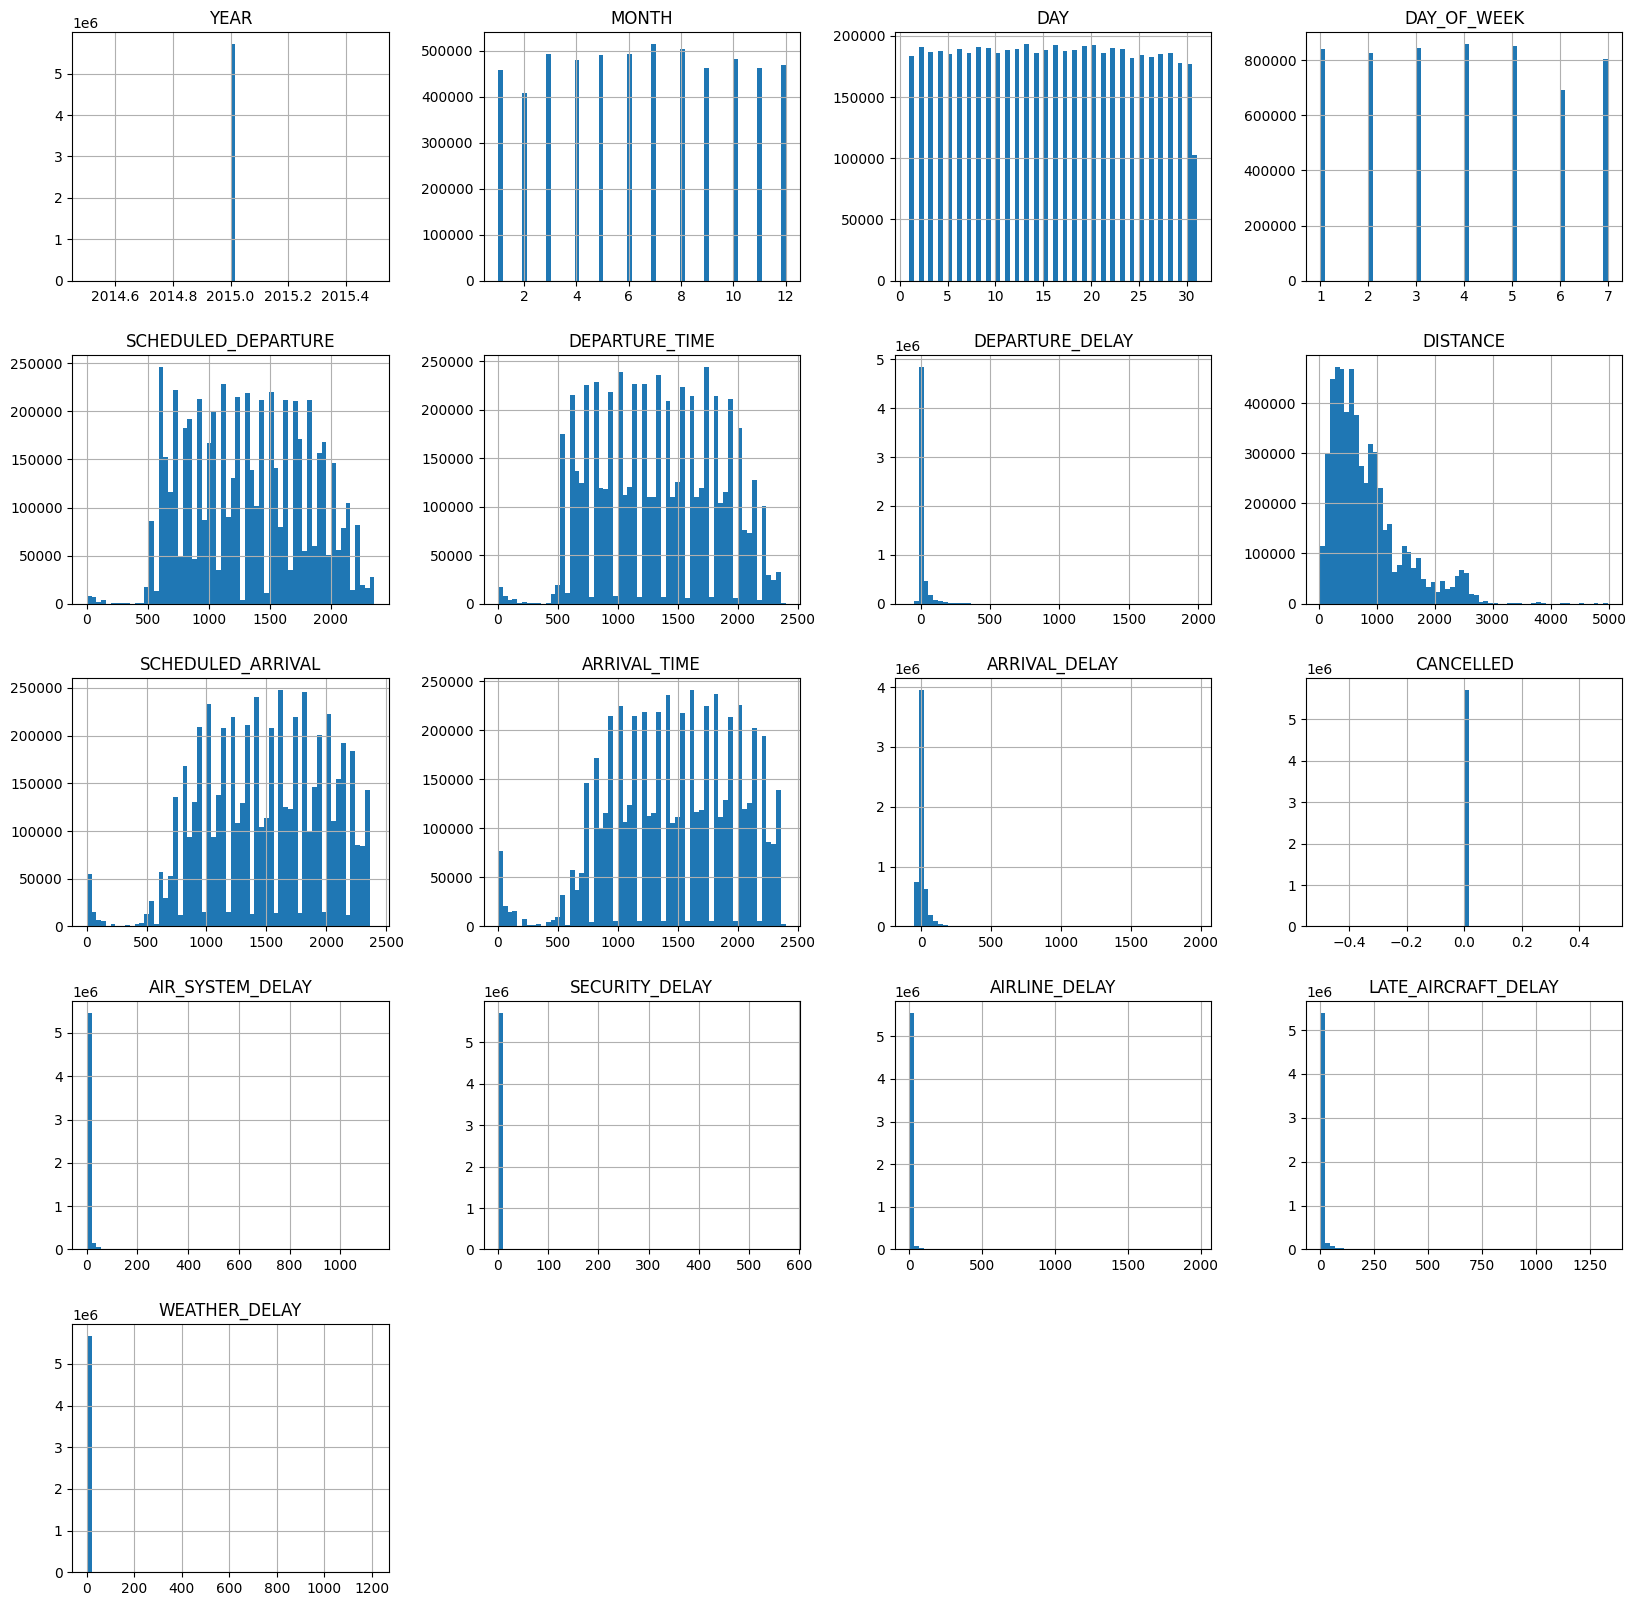

In [19]:
df.hist(bins=60, figsize=(20,20))

In [20]:
df[df['ARRIVAL_DELAY']>1500]

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
264495,2015,1,18,7,AA,LAS,LAX,1130,1414.0,1604.0,236,1246,1519.0,1593.0,0,NaN,0.0,0.0,1593.0,0.0,0.0
337720,2015,1,23,5,AA,BHM,DFW,700,1608.0,1988.0,597,914,1805.0,1971.0,0,NaN,0.0,0.0,1971.0,0.0,0.0
396544,2015,1,27,2,AA,FAT,DFW,659,850.0,1551.0,1313,1210,1356.0,1546.0,0,NaN,0.0,0.0,1546.0,0.0,0.0
886984,2015,2,28,6,AA,STL,MIA,620,847.0,1587.0,1068,1008,1315.0,1627.0,0,NaN,40.0,0.0,1587.0,0.0,0.0
949876,2015,3,4,3,AA,HNL,LAX,828,1057.0,1589.0,2556,1555,1811.0,1576.0,0,NaN,0.0,0.0,1576.0,0.0,0.0
1047179,2015,3,10,2,AA,SAT,DFW,850,1047.0,1557.0,247,1000,1154.0,1554.0,0,NaN,0.0,0.0,1554.0,0.0,0.0
1278418,2015,3,24,2,AA,OMA,DFW,1103,1352.0,1609.0,583,1255,1533.0,1598.0,0,NaN,0.0,0.0,1563.0,35.0,0.0
1290061,2015,3,25,3,AA,SMF,DFW,625,748.0,1523.0,1431,1149,1303.0,1514.0,0,NaN,0.0,0.0,1514.0,0.0,0.0
1841449,2015,4,28,2,AA,SAN,JFK,745,927.0,1542.0,2446,1615,1809.0,1554.0,0,NaN,12.0,0.0,838.0,704.0,0.0
2739880,2015,6,22,1,AA,RIC,DFW,715,837.0,1522.0,1158,920,1028.0,1508.0,0,NaN,0.0,0.0,1508.0,0.0,0.0


In [21]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
       'DEPARTURE_DELAY', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY'],
      dtype='str')

In [22]:
df = df[['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DISTANCE', 'SCHEDULED_ARRIVAL',
       'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY']]

In [23]:
df.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                    str
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DISTANCE                 int64
SCHEDULED_ARRIVAL        int64
ARRIVAL_DELAY          float64
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

In [24]:
df['AIRLINE'].value_counts()

AIRLINE
WN    1242403
DL     870275
AA     712935
OO     576814
EV     554752
UA     507762
MQ     278791
B6     262042
US     194223
AS     171439
NK     115193
F9      90090
HA      76041
VX      61248
Name: count, dtype: int64

In [25]:
df['ORIGIN_AIRPORT'].value_counts()

ORIGIN_AIRPORT
ATL      343506
ORD      276554
DFW      232647
DEN      193402
LAX      192003
          ...  
14222         1
14025         1
13502         1
15497         1
12265         1
Name: count, Length: 929, dtype: int64

In [26]:
len(df['ORIGIN_AIRPORT'].value_counts())

929

In [27]:
len(df['DESTINATION_AIRPORT'].value_counts())

929

In [28]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DISTANCE',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY'],
      dtype='str')

In [29]:
df = df[['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'SCHEDULED_DEPARTURE',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY']]

#TWORZYMY KOLUMNE POMOCNICZĄ

In [30]:
df['ALL_DELAYS'] = df[['AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY']].sum(axis=1)
df['ALL_DELAYS'].value_counts()

ALL_DELAYS
0.0       4650569
15.0        39941
16.0        37719
17.0        35139
18.0        33340
           ...   
1059.0          1
1265.0          1
1115.0          1
1372.0          1
1076.0          1
Name: count, Length: 1143, dtype: int64

In [31]:
df['ALL_DELAYS'] = df[['AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY']].sum(axis=1)
df['DELAY_REASON'] = np.where(df['ALL_DELAYS']>0, df[['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY' , 'LATE_AIRCRAFT_DELAY' , 'WEATHER_DELAY']].idxmax(axis=1), 'NO_DELAY')
df.head(100)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ALL_DELAYS,DELAY_REASON
0,2015,1,1,4,AS,5,430,-22.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
1,2015,1,1,4,AA,10,750,-9.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
2,2015,1,1,4,US,20,806,5.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
3,2015,1,1,4,AA,20,805,-9.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
4,2015,1,1,4,AS,25,320,-21.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,2015,1,1,4,EV,535,800,-3.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
101,2015,1,1,4,OO,535,650,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY
102,2015,1,1,4,UA,538,900,78.0,22.0,0.0,56.0,0.0,0.0,78.0,AIRLINE_DELAY
103,2015,1,1,4,OO,538,710,-16.0,0.0,0.0,0.0,0.0,0.0,0.0,NO_DELAY


In [32]:
df['DELAY_REASON'].value_counts()

DELAY_REASON
NO_DELAY               4650569
LATE_AIRCRAFT_DELAY     410647
AIRLINE_DELAY           311386
AIR_SYSTEM_DELAY        303784
WEATHER_DELAY            35711
SECURITY_DELAY            1911
Name: count, dtype: int64

<Axes: >

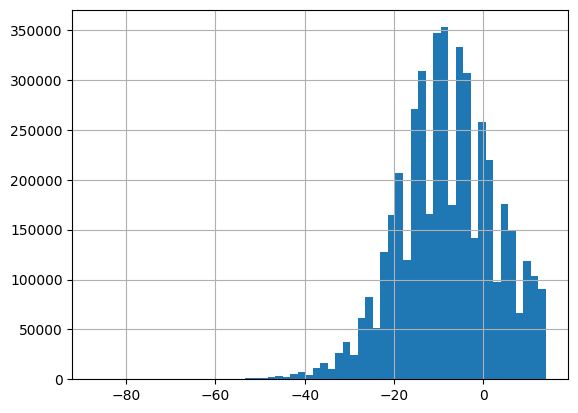

In [33]:
df[df['DELAY_REASON']=='NO_DELAY']['ARRIVAL_DELAY'].hist(bins=60)

In [34]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'SCHEDULED_DEPARTURE',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY', 'ALL_DELAYS', 'DELAY_REASON'],
      dtype='str')

In [35]:
df = df[['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'SCHEDULED_DEPARTURE',
       'SCHEDULED_ARRIVAL', 'DELAY_REASON']]

In [36]:
X_df = df[['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'SCHEDULED_DEPARTURE',
       'SCHEDULED_ARRIVAL']]

X_df = pd.get_dummies(X_df).astype(int)

Y_df = df[['DELAY_REASON']]

In [37]:
X_df

,YEAR,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,AIRLINE_AA,AIRLINE_AS,AIRLINE_B6,AIRLINE_DL,AIRLINE_EV,AIRLINE_F9,AIRLINE_HA,AIRLINE_MQ,AIRLINE_NK,AIRLINE_OO,AIRLINE_UA,AIRLINE_US,AIRLINE_VX,AIRLINE_WN
0,2015,1,1,4,5,430,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,2015,1,1,4,10,750,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2015,1,1,4,20,806,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,2015,1,1,4,20,805,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2015,1,1,4,25,320,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,2359,819,0,0,1,0,0,0,0,0,0,0,0,0,0,0
5819075,2015,12,31,4,2359,446,0,0,1,0,0,0,0,0,0,0,0,0,0,0
5819076,2015,12,31,4,2359,440,0,0,1,0,0,0,0,0,0,0,0,0,0,0
5819077,2015,12,31,4,2359,340,0,0,1,0,0,0,0,0,0,0,0,0,0,0


In [38]:
Y_df

,DELAY_REASON
0,NO_DELAY
1,NO_DELAY
2,NO_DELAY
3,NO_DELAY
4,NO_DELAY
...,...
5819074,NO_DELAY
5819075,NO_DELAY
5819076,NO_DELAY
5819077,NO_DELAY


#ONE HOT ENCODING DLA KOLUMNY AIRLINE

#TRENOWANIE MODELU Z scikit-learn

In [39]:
X_train , X_test , y_train , y_test = train_test_split(X_df, Y_df, test_size=0.30, random_state=10)
y_train.value_counts()

DELAY_REASON       
NO_DELAY               3254905
LATE_AIRCRAFT_DELAY     287514
AIRLINE_DELAY           217840
AIR_SYSTEM_DELAY        213197
WEATHER_DELAY            25013
SECURITY_DELAY            1336
Name: count, dtype: int64

In [40]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
from imblearn.over_sampling import RandomOverSampler

rus = RandomOverSampler(random_state=0)
X_resampled, y_resampled = rus.fit_resample(X_train,y_train)

#TAK NAPRAWDE POWINNIŚMY UZYĆ TUTAJ OPCJI RandomOverSampler ale ta wersja colab nie dźwiga tego ramowo przy wybranej przez mnie bazie danych

In [42]:
print("rozkład klas po resamplingu")
print(y_resampled.value_counts())

rozkład klas po resamplingu
DELAY_REASON       
NO_DELAY               3254905
AIR_SYSTEM_DELAY       3254905
LATE_AIRCRAFT_DELAY    3254905
AIRLINE_DELAY          3254905
WEATHER_DELAY          3254905
SECURITY_DELAY         3254905
Name: count, dtype: int64


In [ ]:
clf= DecisionTreeClassifier(class_weight='balanced',random_state=0).fit(X_train,y_train)

In [44]:
y_pred = clf.predict(X_test)

In [45]:
y_pred

array(['AIR_SYSTEM_DELAY', 'NO_DELAY', 'NO_DELAY', ..., 'NO_DELAY',
       'NO_DELAY', 'NO_DELAY'], shape=(1714203,), dtype=object)

In [46]:
print("dokładnośc modelu na oryginalnych danych:", clf.score(X_test,y_test))

dokładnośc modelu na oryginalnych danych: 0.6910010074652768


In [47]:
clf_resampled = DecisionTreeClassifier(random_state=0).fit(X_resampled, y_resampled)

In [48]:
y_pred_resampled = clf_resampled.predict(X_test)

In [49]:
print("dokładność po resamplingu ale z UnderSampler (z powodu braku ramu): ", clf_resampled.score(X_test,y_test))

dokładność po resamplingu ale z UnderSampler (z powodu braku ramu):  0.6920335572858057


In [50]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred_resampled, labels = clf_resampled.classes_)

In [51]:
cm

array([[   8823,    6309,    9812,   67718,      53,     831],
       [   6309,   12769,    8687,   61752,      38,    1032],
       [  10338,    8966,   21710,   80644,      54,    1421],
       [  80300,   71495,   93689, 1142138,     497,    7545],
       [     39,      46,      53,     417,      11,       9],
       [    865,    1143,    1342,    6509,       4,     835]])

In [52]:
import seaborn as sns

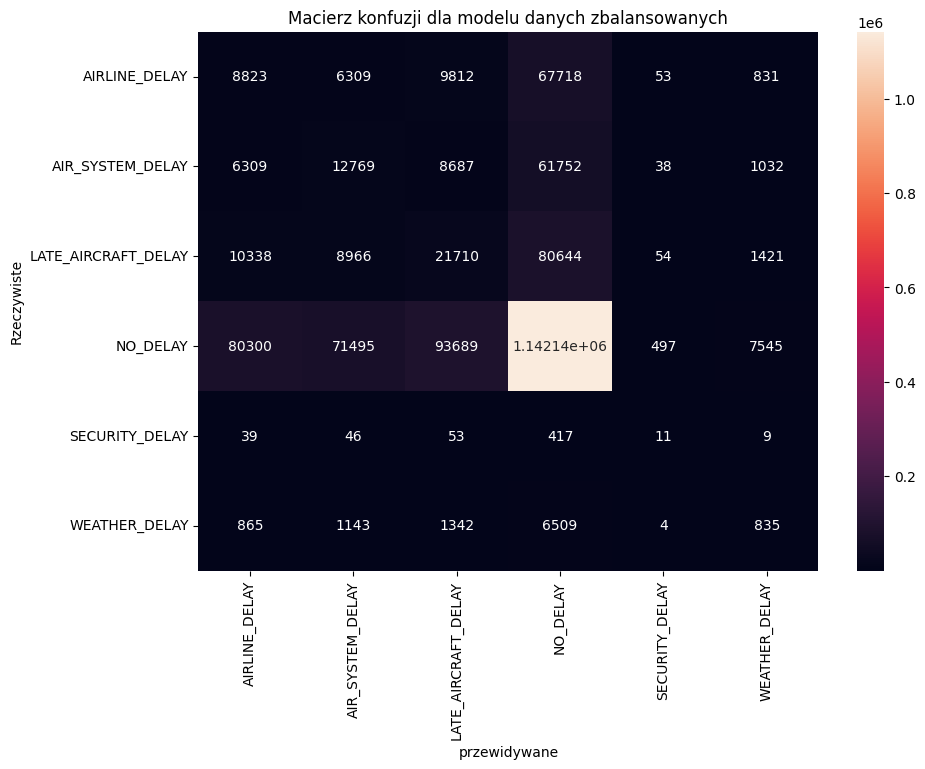

In [53]:
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=clf_resampled.classes_, yticklabels=clf_resampled.classes_)
plt.xlabel("przewidywane")
plt.ylabel("Rzeczywiste")
plt.title("Macierz konfuzji dla modelu danych zbalansowanych")
plt.show()

In [54]:
print(classification_report(y_test,y_pred_resampled))

                     precision    recall  f1-score   support

      AIRLINE_DELAY       0.08      0.09      0.09     93546
   AIR_SYSTEM_DELAY       0.13      0.14      0.13     90587
LATE_AIRCRAFT_DELAY       0.16      0.18      0.17    123133
           NO_DELAY       0.84      0.82      0.83   1395664
     SECURITY_DELAY       0.02      0.02      0.02       575
      WEATHER_DELAY       0.07      0.08      0.07     10698

           accuracy                           0.69   1714203
          macro avg       0.22      0.22      0.22   1714203
       weighted avg       0.71      0.69      0.70   1714203



#WIDZIMY TUTAJ,ŻE NASZ MODEL JEST LENIWY, NAJŁATWIEJ MU PRZEWIDZIEĆ NO_DELAY WIĘC IDZIE NA SKRÓTY.

#podzieliliśmy dane, zniwelowaliśmy niezbalansowane klasy, wytrenowalismy model na defaultowych parametrach i sprobujemy znaleźć najlepsze hiperparametry dla trenowania naszego modelu , żeby jego predykcje były "lepsze"

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn import svm

parameters = {'max_depth':[10,15], 'max_features':["sqrt", "log2"]}
tree = DecisionTreeClassifier()
clf = GridSearchCV(tree,parameters)

In [56]:
clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15], 'max_features': ['sqrt', 'log2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information prin

In [57]:
y_pred = clf.predict(X_test)

In [58]:
print(classification_report(y_test, y_pred))

C:\Users\patry\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\patry\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                     precision    recall  f1-score   support

      AIRLINE_DELAY       0.05      0.00      0.00     93546
   AIR_SYSTEM_DELAY       0.28      0.00      0.00     90587
LATE_AIRCRAFT_DELAY       0.24      0.00      0.00    123133
           NO_DELAY       0.81      1.00      0.90   1395664
     SECURITY_DELAY       0.00      0.00      0.00       575
      WEATHER_DELAY       0.00      0.00      0.00     10698

           accuracy                           0.81   1714203
          macro avg       0.23      0.17      0.15   1714203
       weighted avg       0.70      0.81      0.73   1714203



C:\Users\patry\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [59]:
from sklearn.model_selection import cross_val_score

clf= DecisionTreeClassifier(random_state=0)
cross_val_score(clf, X_df,Y_df, cv=10)

array([0.37601089, 0.08689869, 0.0735088 , 0.0114403 , 0.01096953,
       0.01902167, 0.02945217, 0.00758487, 0.14271789, 0.18097305])

In [ ]:
#KNN
#inicjalizacja model
knn_model = KNeighborsClassifier(n_neighbors=3)
#trening modelu
knn_model.fit(X_resampled, y_resampled)
#testowanie skutecznosci modelu
knn_predict = knn_model.predict(X_test)
#raport
print(classification_report(y_test, knn_predict))